In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\slpmi\OneDrive\Desktop\Healthcare\data\StrokeData_Unprocessed.csv")
df.head(7)

,id,gender,age,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,hypertension,heart_disease
0,9046,Male,67.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1,0,1
1,51676,Female,61.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,0,0
2,31112,Male,80.0,Yes,Private,Rural,105.92,32.5,never smoked,1,0,1
3,60182,Female,49.0,Yes,Private,Urban,171.23,34.4,smokes,1,0,0
4,1665,Female,79.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,1,0
5,56669,Male,81.0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,0,0
6,53882,Male,74.0,Yes,Private,Rural,70.09,27.4,never smoked,1,1,1


In [3]:
print("Dataset Dimension : ", df.shape)

Dataset Dimension :  (5110, 12)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   ever_married       5110 non-null   str    
 4   work_type          5110 non-null   str    
 5   Residence_type     5110 non-null   str    
 6   avg_glucose_level  5110 non-null   float64
 7   bmi                4909 non-null   float64
 8   smoking_status     5110 non-null   str    
 9   stroke             5110 non-null   int64  
 10  hypertension       5110 non-null   int64  
 11  heart_disease      5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [5]:
df.describe()

,id,age,avg_glucose_level,bmi,stroke,hypertension,heart_disease
count,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,106.147677,28.893237,0.048728,0.097456,0.054012
std,21161.721625,22.612647,45.283560,7.854067,0.215320,0.296607,0.226063
min,67.000000,0.080000,55.120000,10.300000,0.000000,0.000000,0.000000
25%,17741.250000,25.000000,77.245000,23.500000,0.000000,0.000000,0.000000
50%,36932.000000,45.000000,91.885000,28.100000,0.000000,0.000000,0.000000
75%,54682.000000,61.000000,114.090000,33.100000,0.000000,0.000000,0.000000
max,72940.000000,82.000000,271.740000,97.600000,1.000000,1.000000,1.000000


In [6]:
print("Missing values:\n",df.isnull().sum())

Missing values:
 id                     0
gender                 0
age                    0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
hypertension           0
heart_disease          0
dtype: int64


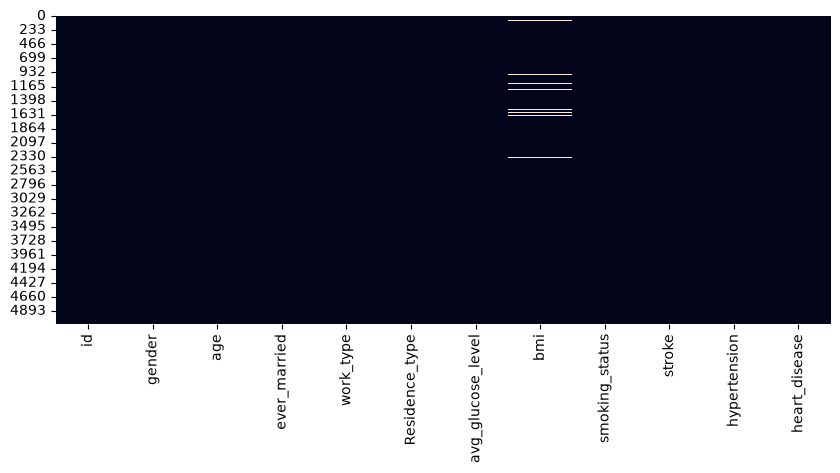

In [8]:
plt.figure(figsize = (10,4))
sns.heatmap(df.isnull(),cbar = False)
plt.show()


In [10]:
missing_value_percent = (df.isnull().sum()/len(df))*100
print(missing_value_percent)

id                   0.000000
gender               0.000000
age                  0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
hypertension         0.000000
heart_disease        0.000000
dtype: float64


In [12]:
print(f"Duplicate count in the dataset :\n{df.duplicated().sum()}")

Duplicate count in the dataset :
0


In [34]:
numerical_columns = df.select_dtypes(include = ['number'] ).columns.tolist()
print(f"Numerical columns : {numerical_columns}")
categorical_columns = df.select_dtypes(include = ['object','category']).columns.tolist()
print(f"Categorical columns : {categorical_columns}")

Numerical columns : ['id', 'age', 'avg_glucose_level', 'bmi', 'stroke', 'hypertension', 'heart_disease']
Categorical columns : ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


C:\Users\slpmi\AppData\Local\Temp\ipykernel_14932\1222369774.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include = ['object','category']).columns.tolist()


stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


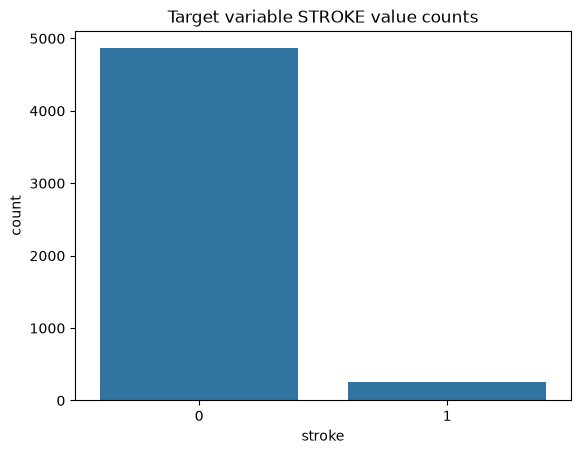

In [20]:
# Target Variable Analysis
print(df["stroke"].value_counts(normalize = True)*100)
sns.countplot(data = df, x = "stroke")
plt.title("Target variable STROKE value counts")
plt.show()

heart_disease
0    94.598826
1     5.401174
Name: proportion, dtype: float64


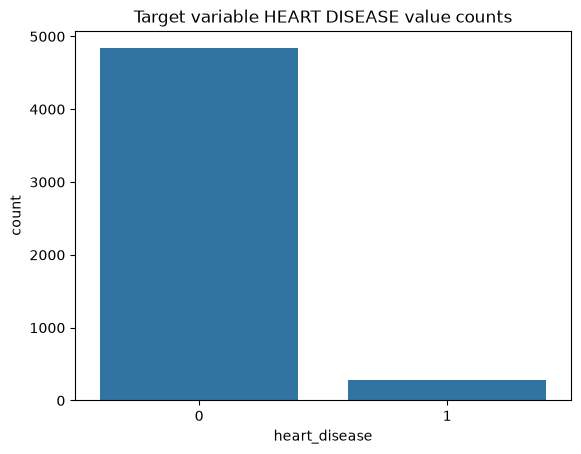

In [22]:
print(df["heart_disease"].value_counts(normalize = True)* 100)
sns.countplot(data = df, x = "heart_disease")
plt.title("Target variable HEART DISEASE value counts")
plt.show()

hypertension
0    90.254403
1     9.745597
Name: proportion, dtype: float64


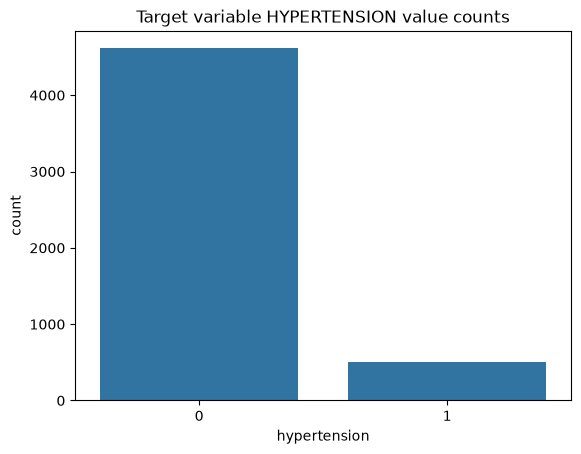

In [24]:
print(df['hypertension'].value_counts(normalize = True)*100)
sns.countplot(data = df,x = "hypertension")
plt.title("Target variable HYPERTENSION value counts")
plt.show()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


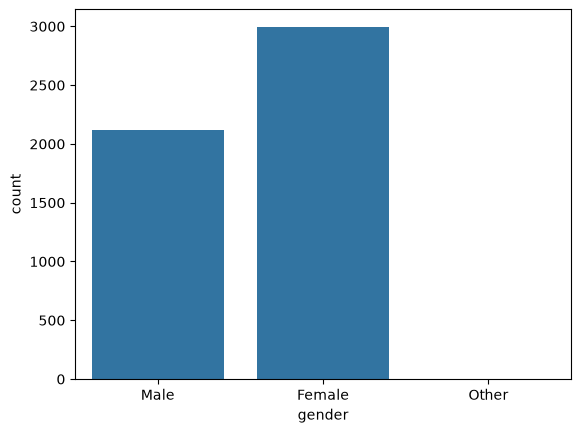

In [36]:
print(df["gender"].value_counts())
sns.countplot(data = df, x = "gender")
plt.show()

ever_married
Yes    3353
No     1757
Name: count, dtype: int64


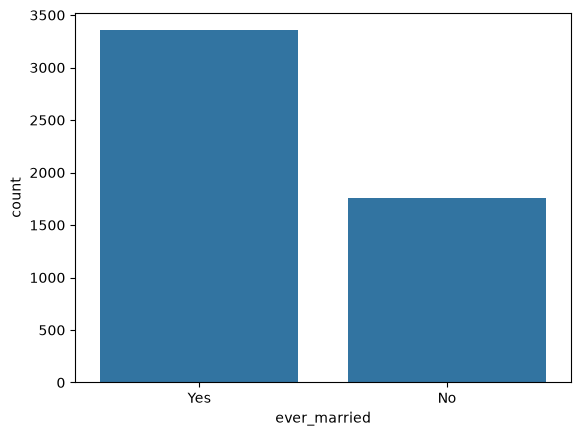

In [38]:
print(df["ever_married"].value_counts())
sns.countplot(data = df, x = "ever_married")
plt.show()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64


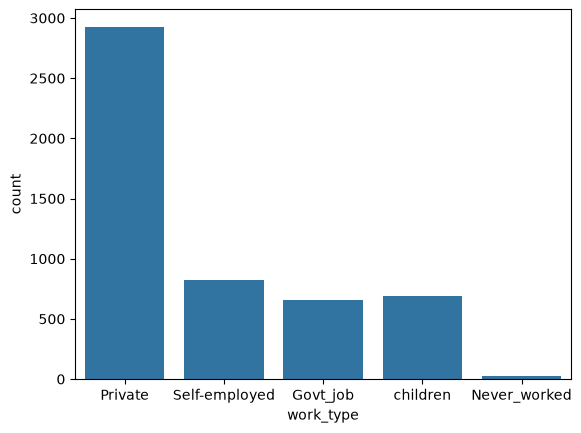

In [39]:
print(df["work_type"].value_counts())
sns.countplot(data = df, x = "work_type")
plt.show()

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64


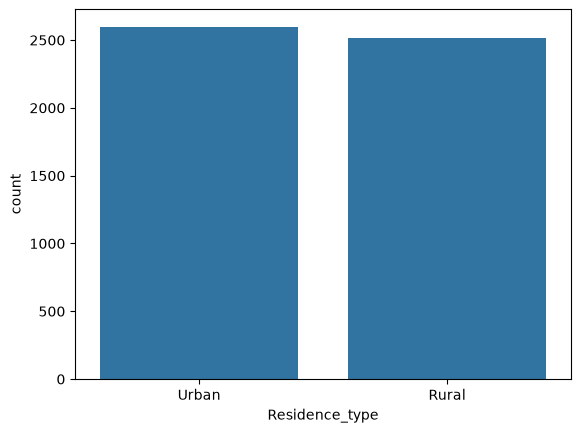

In [41]:
print(df["Residence_type"].value_counts())
sns.countplot(data = df, x = "Residence_type")
plt.show()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


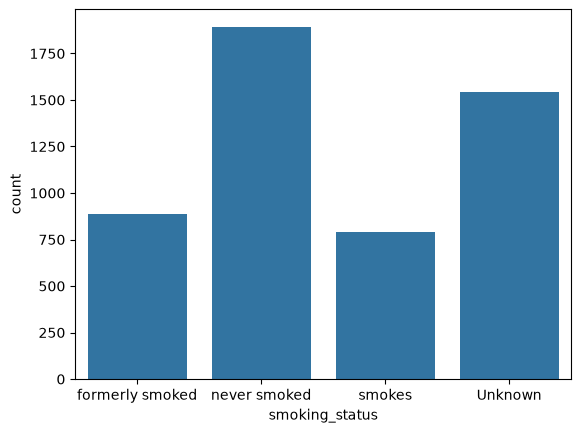

In [42]:
print(df["smoking_status"].value_counts())
sns.countplot(data = df, x = "smoking_status")
plt.show()

Text(0.5, 1.0, 'Age distribution')

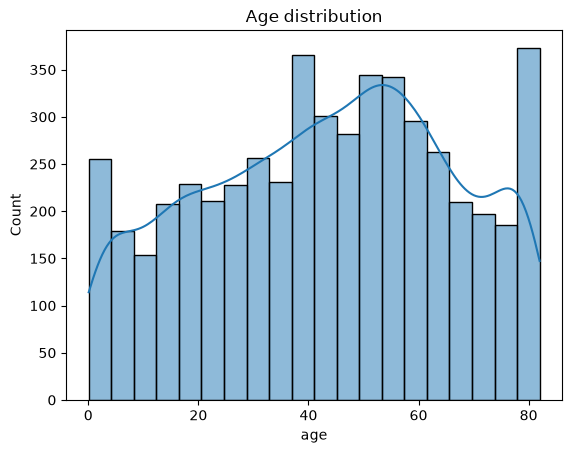

In [49]:
sns.histplot(df["age"],kde = True)
plt.title("Age distribution")

Text(0.5, 1.0, 'Average Glucose Level distribution')

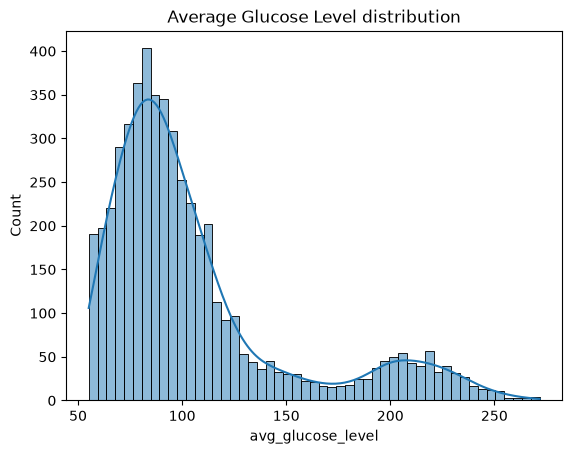

In [51]:
sns.histplot(df["avg_glucose_level"],kde = True)
plt.title("Average Glucose Level distribution")

Text(0.5, 1.0, 'BMI distribution')

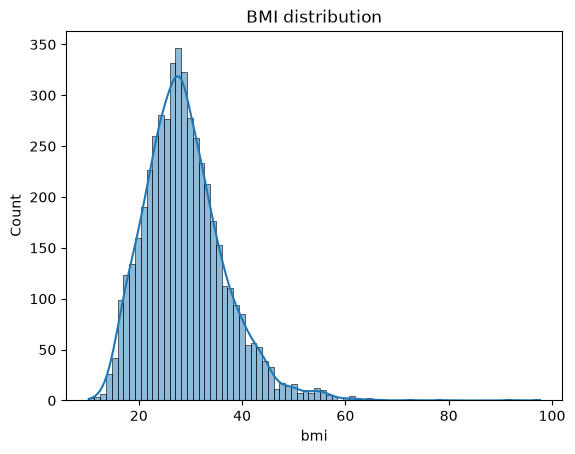

In [52]:
sns.histplot(df["bmi"],kde = True)
plt.title("BMI distribution")

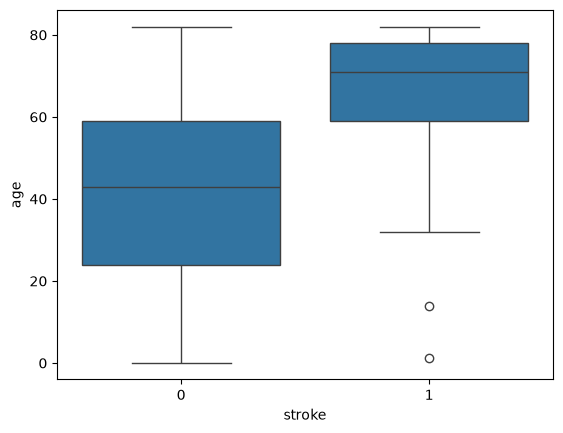

In [56]:
sns.boxplot(data = df, x = "stroke", y = "age")
plt.show()

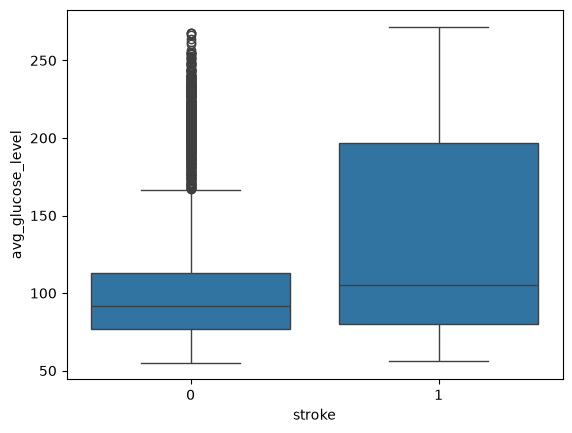

In [58]:
sns.boxplot(data = df, x = "stroke", y = "avg_glucose_level")
plt.show()

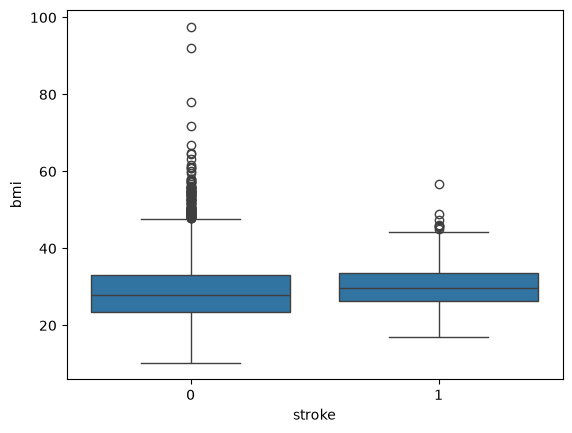

In [59]:
sns.boxplot(data = df, x = "stroke", y = "bmi")
plt.show()

In [67]:
print(pd.crosstab(df["smoking_status"],df["stroke"]))

stroke              0   1
smoking_status           
Unknown          1497  47
formerly smoked   815  70
never smoked     1802  90
smokes            747  42


In [68]:
print(pd.crosstab(df["gender"],df["stroke"]))

stroke     0    1
gender           
Female  2853  141
Male    2007  108
Other      1    0


In [69]:
print(pd.crosstab(df["ever_married"],df["stroke"]))

stroke           0    1
ever_married           
No            1728   29
Yes           3133  220


In [70]:
print(pd.crosstab(df["work_type"],df["stroke"]))

stroke            0    1
work_type               
Govt_job        624   33
Never_worked     22    0
Private        2776  149
Self-employed   754   65
children        685    2


In [71]:
print(pd.crosstab(df["Residence_type"],df["stroke"]))

stroke             0    1
Residence_type           
Rural           2400  114
Urban           2461  135


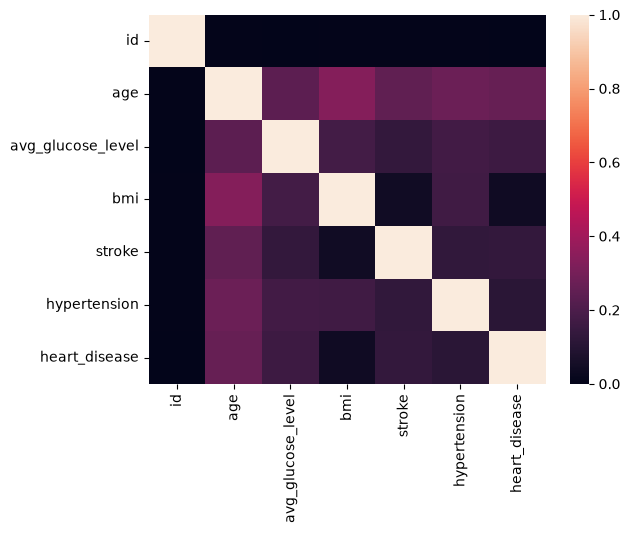

In [74]:
numerics = df.select_dtypes(include = np.number)
sns.heatmap(numerics.corr())
plt.show()

In [75]:
print("Exploratory Data Analysis Findings:")
print("1. BMI has missing values\n2.Target variables [stroke, heartdisease] are highly imbalanced\n3.No dulpicates\n4.Categorical variables require encoding")

Exploratory Data Analysis Findings:
1. BMI has missing values
2.Target variables [stroke, heartdisease] are highly imbalanced
3.No dulpicates
4.Categorical variables require encoding
